#Pengaruh Kondisi Cuaca dan Traffic terhadap Waktu Pengiriman Makanan: Analisis Berbasis Data Untuk Estimasi Waktu Pengiriman yang Lebih Realistis

###Waktu pengiriman adalah salah satu faktor penentu utama kepuasan pelanggan dalam layanan food delivery. Keterlambatan, meskipun kecil dapat memicu komplain, permintaan refund, hingga penurunan loyalitas pelanggan. Dalam praktiknya, estimasi waktu pengiriman (ETA) yang ditampilkan ke pelanggan umumnya bersifat statis dan belum tentu mempertimbangkan kondisi operasional aktual seperti cuaca dan tingkat kepadatan lalu lintas (traffic) saat pesanan berlangsung. Padahal, kedua faktor ini kerap dianggap berpengaruh besar terhadap performa pengiriman. Namun anggapan tersebut belum tentu terbukti secara data, dan besarnya pengaruh tersebut pun belum terkuantifikasi.

###Dataset Food_Delivery_Times.csv, yang mencakup 1.000 data pengiriman dengan atribut cuaca, traffic, jenis kendaraan, waktu pemesanan, jarak tempuh, dan pengalaman kurir, memberikan kesempatan untuk menguji secara statistik faktor-faktor mana yang benar-benar signifikan mempengaruhi waktu pengiriman, sekaligus mengukur seberapa besar kontribusinya — sebagai dasar pengambilan keputusan operasional yang lebih berbasis data.

###Business Problem
###1.) Ekspektasi pelanggan tidak terkendali akibat estimasi waktu yang tidak adaptif terhadap kondisi lapangan. Pesanan yang terlambat karena kombinasi cuaca buruk dan traffic padat tetap dinilai "telat dari janji", padahal keterlambatan tersebut merupakan konsekuensi wajar dari kondisi operasional,bukan kegagalan layanan.

###2.) Belum diketahui secara pasti faktor operasional mana yang benar-benar berpengaruh signifikan terhadap waktu pengiriman. Selama ini cuaca, traffic, jenis kendaraan, dan waktu pemesanan sering dianggap sama-sama relevan, sehingga berisiko terjadi salah alokasi perhatian atau sumber daya pada faktor yang sebenarnya tidak berdampak signifikan.

###3.) Belum ada kuantifikasi untuk seberapa besar dampak kombinasi kondisi buruk terhadap waktu pengiriman, sehingga perusahaan sulit menyusun kebijakan buffer waktu atau SLA yang proporsional untuk skenario-skenario ekstrem (misalnya traffic tinggi bersamaan dengan hujan).

###4.) Risiko peningkatan volume komplain dan beban kompensasi akibat gap antara ekspektasi yang diberikan ke pelanggan dan realita waktu pengiriman di lapangan, tanpa adanya dasar data yang memadai sebagai upaya mitigasi.

## A.) Quick Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from datetime import timedelta
from google.colab import files

pd.set_option('display.max_colwidth', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Dibimbing/THT/Food_Delivery_Times.csv')
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


## B.) Data Cleaning & Quality Check

In [ ]:
#Quick data quality check

Summary = pd.DataFrame({
    'dtype': df.dtypes,
    'Missing': df.isnull().sum(),
    'Duplicated': df.duplicated().sum(),
    'Unique': df.nunique(),
})
Summary

,dtype,Missing,Duplicated,Unique
Order_ID,int64,0,0,1000
Distance_km,float64,0,0,785
Weather,object,30,0,5
Traffic_Level,object,30,0,3
Time_of_Day,object,30,0,4
Vehicle_Type,object,0,0,3
Preparation_Time_min,int64,0,0,25
Courier_Experience_yrs,float64,30,0,10
Delivery_Time_min,int64,0,0,108


In [ ]:
#Unique values dari masing-masing metrik

obj_cols = [c for c in df.select_dtypes(include='object').columns]
cols_to_check = obj_cols + ['Courier_Experience_yrs']

unique_df = pd.DataFrame({
    'unique_count': df[cols_to_check].nunique(),
    'unique_values': [sorted(df[col].dropna().unique().tolist()) for col in cols_to_check]
})
unique_df

,unique_count,unique_values
Weather,5,"[Clear, Foggy, Rainy, Snowy, Windy]"
Traffic_Level,3,"[High, Low, Medium]"
Time_of_Day,4,"[Afternoon, Evening, Morning, Night]"
Vehicle_Type,3,"[Bike, Car, Scooter]"
Courier_Experience_yrs,10,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]"


#### Dataset terdiri dari 1.000 baris tanpa data duplikat sama sekali (semua kolom Duplicated = 0). Empat kolom mengalami missing value dengan pola serupa, Weather, Traffic_Level, Time_of_Day, dan Courier_Experience_yrs masing-masing kehilangan 30 baris (3% dari total baris keseluruhan). Sementara enam kolom lainnya lengkap 100%. Dari sisi variasi nilai, seluruh kolom kategorikal punya struktur yang jelas dan terbatas (bukan free-text), sehingga siap dipakai untuk grouping tanpa perlu standardisasi label lebih lanjut.

####Sedangkan untuk missing values, penghapusan seluruh baris yang memiliki missing value berpotensi mengurangi ukuran sampel dan kehilangan sebagian informasi yang masih dapat digunakan. Oleh karena itu, dilakukan imputasi untuk mempertahankan jumlah observasi yang tersedia. Pemilihan metode imputasi disesuaikan dengan tipe data dan karakteristik masing-masing variabel.

#### - Weather: 5 kategori (Clear, Foggy, Rainy, Snowy, Windy) => diimputasi dengan modus (Clear), karena porsi missing yang kecil (3%) membuat nilai terbanyak jadi tebakan paling representatif tanpa menggeser distribusi kategori secara signifikan

#### - Traffic_Level: 3 kategori (Low, Medium, High) => diimputasi dengan modus, dengan alasan yang sama seperti Weather

#### - Time_of_Day: 4 kategori (Morning, Afternoon, Evening, Night) => diimputasi dengan modus, dengan alasan yang sama seperti Weather

#### - Vehicle_Type: 3 kategori (Bike, Car, Scooter), tidak ada missing value

#### - Courier_Experience_yrs: 10 nilai unik, bilangan bulat 0–9 tahun => diimputasi dengan median, karena lebih tahan terhadap outlier dibanding mean dan cocok untuk data pengalaman kerja yang biasanya skewed






## B.1) Handle Missing Values

In [ ]:
df_clean = df.copy()

for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

df_clean['Courier_Experience_yrs'] = df_clean['Courier_Experience_yrs'].fillna(
    df_clean['Courier_Experience_yrs'].median()
)

assert df_clean.isna().sum().sum() == 0
df_clean.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


## C.)  EDA

###C.1) Deskripsi Data Durasi Pengiriman Order (Delivery_Time_min)

In [ ]:
df_clean['Delivery_Time_min'].describe()

,Delivery_Time_min
count,1000.000000
mean,56.732000
std,22.070915
min,8.000000
25%,41.000000
50%,55.500000
75%,71.000000
max,153.000000


##C.2) Distribusi Data Durasi Pengiriman

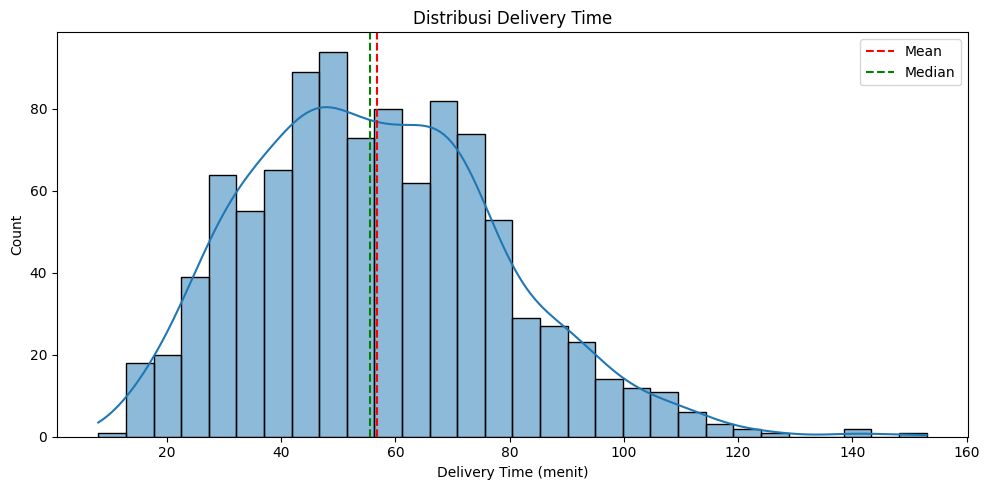

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(df_clean['Delivery_Time_min'], bins=30, kde=True)
plt.axvline(df_clean['Delivery_Time_min'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df_clean['Delivery_Time_min'].median(), color='green', linestyle='--', label='Median')
plt.title('Distribusi Delivery Time')
plt.xlabel('Delivery Time (menit)')
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
print("Skewness waktu pengiriman:", df_clean['Delivery_Time_min'].skew())

Skewness waktu pengiriman: 0.5072511816152696


##C.3) IQR Analysis

In [ ]:
s = df["Delivery_Time_min"]

q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1

batas_bawah = q1 - 1.5 * iqr
batas_atas = q3 + 1.5 * iqr

outlier = df_clean.loc[(s < batas_bawah) | (s > batas_atas)].sort_values("Delivery_Time_min")

print(f"Q1           : {q1:.2f}")
print(f"Q3           : {q3:.2f}")
print(f"IQR          : {iqr:.2f}")
print(f"Batas bawah  : {batas_bawah:.2f}")
print(f"Batas atas   : {batas_atas:.2f}")
print("\n                                                           Pesanan yang terindikasi Outlier")
display(outlier)



Q1           : 41.00
Q3           : 71.00
IQR          : 30.00
Batas bawah  : -4.00
Batas atas   : 116.00

                                                           Pesanan yang terindikasi Outlier


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
924,428,17.81,Windy,High,Evening,Bike,21,4.0,122
29,948,18.05,Clear,Medium,Evening,Scooter,10,7.0,123
784,385,14.83,Rainy,Low,Morning,Car,19,4.0,126
127,446,18.97,Clear,Low,Evening,Car,25,4.0,141
452,394,15.64,Rainy,Low,Morning,Bike,20,4.0,141
379,814,18.46,Clear,Medium,Morning,Scooter,29,1.0,153


####Distribusi waktu pengiriman dianalisis berdasarkan 1.000 observasi pada variabel Delivery_Time_min. Rata-rata sebesar 56,73 menit hanya sedikit lebih tinggi daripada median sebesar 55,50 menit. Perbedaan yang kecil itu konsisten dengan histogram pada poin C.2, di mana garis mean dan median terletak berdekatan. Dengan demikian, pusat sebaran relatif stabil dan tidak terpengaruh secara material oleh nilai ekstrem.

####Ringkasan kuartil pada poin C.3 memperkuat temuan tersebut. Nilai Q1 sebesar 41,00 menit dan Q3 sebesar 71,00 menit menghasilkan IQR 30,00 menit, sehingga 50 persen waktu pengiriman pesanan berada pada selang 41–71 menit. Enam pesanan (0,6 persen) berada di atas 116 menit, yaitu pada rentang 122–153 menit. Jumlah tersebut terlalu kecil untuk menggeser pusat distribusi, tetapi menandai pesanan yang jauh lebih lambat dari pola umum.

##C.4.) Breakdown per Kategori





      --- Weather ---
         mean  median  count
Weather                     
Clear    53.2    52.0    500
Foggy    59.5    59.0    103
Rainy    59.8    57.5    204
Snowy    67.1    66.0     97
Windy    55.5    55.0     96

      --- Traffic_Level ---
               mean  median  count
Traffic_Level                     
High           64.8    65.0    197
Low            52.9    51.0    383
Medium         56.5    54.0    420

      --- Vehicle_Type ---
              mean  median  count
Vehicle_Type                     
Bike          56.6    56.0    503
Car           58.2    56.0    195
Scooter       56.0    54.5    302

      --- Time_of_Day ---
             mean  median  count
Time_of_Day                     
Afternoon    56.1    56.0    284
Evening      57.5    56.0    293
Morning      57.0    56.5    338
Night        55.2    52.0     85



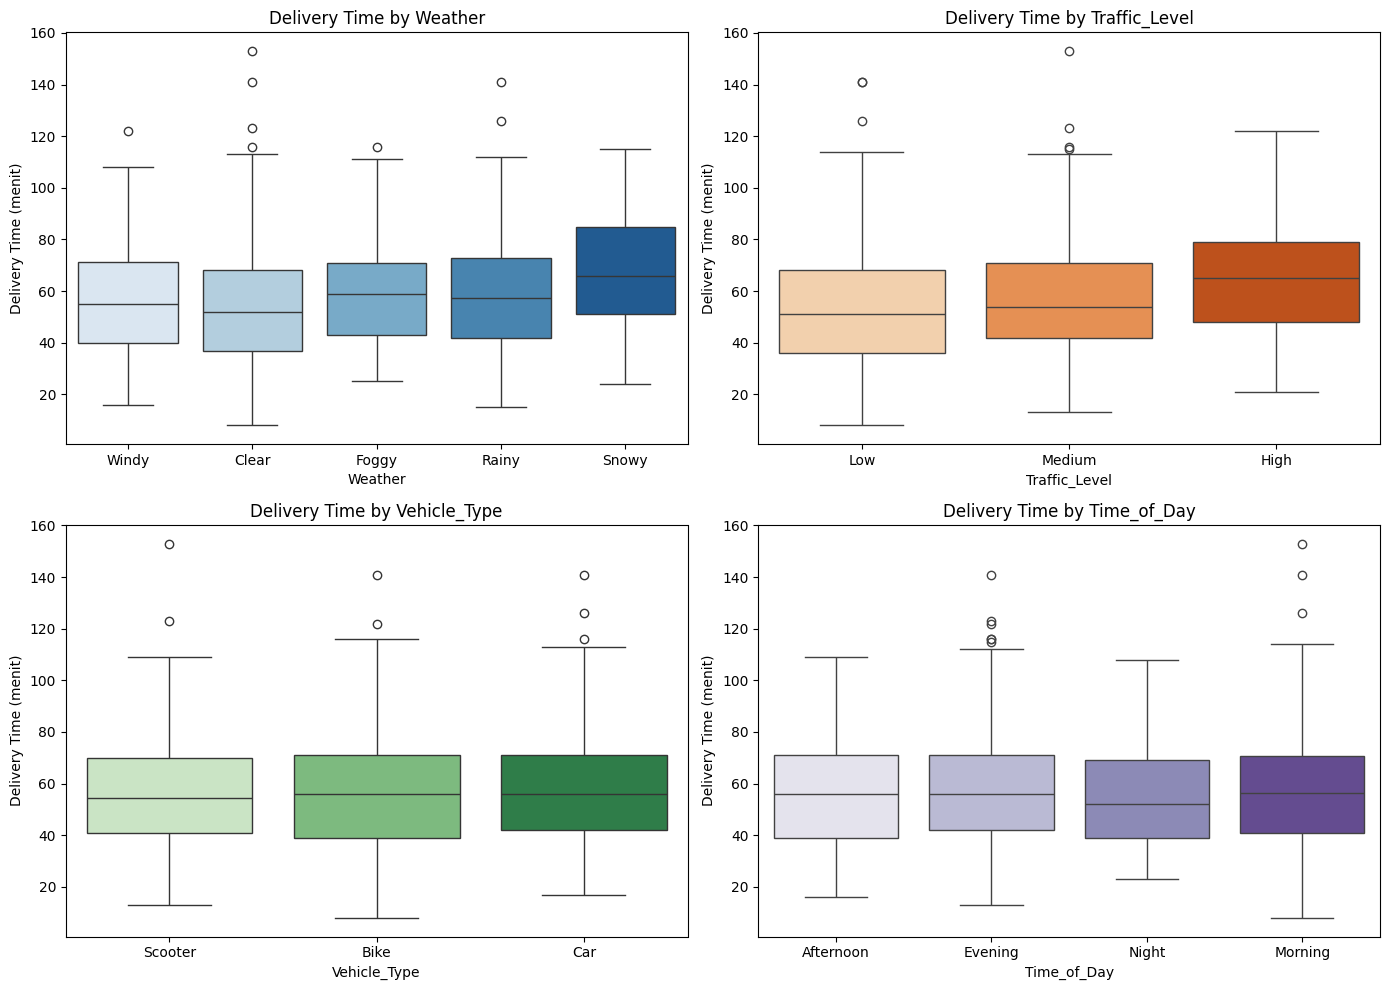

In [ ]:
for col in ['Weather', 'Traffic_Level', 'Vehicle_Type', 'Time_of_Day']:
    print(f'      --- {col} ---')
    print(df_clean.groupby(col)['Delivery_Time_min'].agg(['mean', 'median', 'count']).round(1))
    print()

palettes = {
    'Weather': 'Blues',
    'Traffic_Level': 'Oranges',
    'Vehicle_Type': 'Greens',
    'Time_of_Day': 'Purples'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col, cmap) in zip(axes.flat, palettes.items()):
    sns.boxplot(data=df_clean, x=col, y='Delivery_Time_min', hue=col, palette=cmap, legend=False, ax=ax)
    ax.set_title(f'Delivery Time by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Delivery Time (menit)')
plt.tight_layout()
plt.show()

####Boxplot per kategori menunjukkan bahwa mayoritas kondisi operasional memiliki median delivery time yang relatif berdekatan, di rentang 51–59 menit yang mencakup seluruh kategori Vehicle_Type dan Time_of_Day, serta sebagian besar Weather (Windy, Clear, Foggy, Rainy) dan Traffic_Level (Low, Medium).

####Dua pengecualian dengan median tertinggi adalah kondisi cuaca Snowy (median 66 menit) dan traffic level High (median 65 menit). Keduanya menonjol secara visual dibanding kategori lain dalam variabelnya masing-masing, dengan jarak antar-kuartil (IQR) yang juga lebih lebar, mengindikasikan variasi waktu pengiriman yang lebih besar pada kondisi tersebut.

####Sebaliknya, Vehicle_Type dan Time_of_Day tidak menunjukkan pola pembeda yang jelas. Box dan median dari Scooter, Bike, dan Car nyaris tumpang tindih, begitu pula antar Morning, Afternoon, Evening, dan Night. Pola ini secara visual menunjukan bahwa cuaca dan traffic lebih berperan dalam variasi waktu pengiriman dibanding jenis kendaraan atau waktu pemesanan.

##C.5.) Kombinasi Traffic × Cuaca

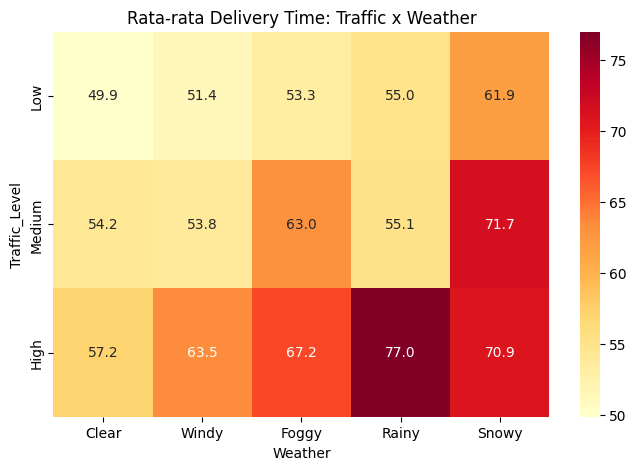

In [ ]:
pivot = df_clean.pivot_table(
    index='Traffic_Level', columns='Weather',
    values='Delivery_Time_min', aggfunc='mean'
).round(1)

order_t = ['Low', 'Medium', 'High']
order_w = ['Clear', 'Windy', 'Foggy', 'Rainy', 'Snowy']
pivot = pivot.reindex(index=order_t, columns=order_w)

plt.figure(figsize=(8, 5))

sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Rata-rata Delivery Time: Traffic x Weather')
plt.show()

####Secara kumulatif, kondisi "Snowy" memberikan dampak yang paling konsisten berat terhadap delivery time di semua level traffic (rata-rata 68,2 menit). Namun, skenario tunggal paling ekstrem justru terjadi pada kombinasi "Rainy" + traffic "High" (77 menit). Hal ini mengindikasikan bahwa adanya efek interaksi, di mana dampak hujan jauh lebih parah ketika bersamaan dengan traffic padat, dibanding saat traffic rendah/sedang

##C.6.) Correlation Heatmap, Tingkat Keeratan Hubungan Antara Metrik (Numerik)

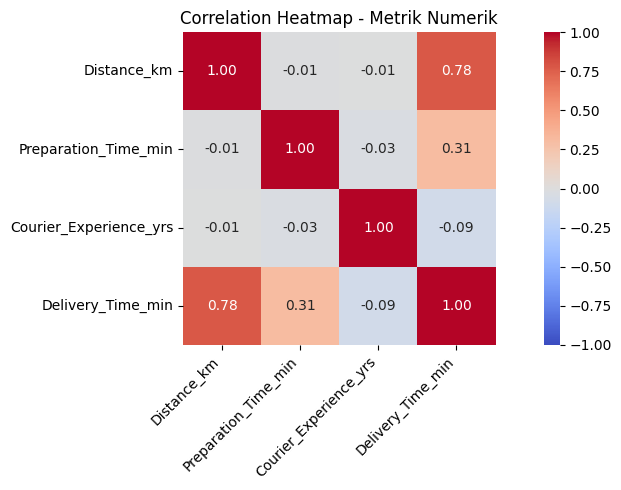

In [ ]:
numeric_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 5))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap - Metrik Numerik')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


####Jarak (Distance_km) adalah prediktor dominan terhadap durasi pengiriman order (Delivery_Time), dengan tingkat korelasi sebesar (r=0,78), diikuti dengan waktu persiapan order dari restoran / rumah makan itu sendiri (Preparation_Time_min) dengan pengaruh sedang yaitu sebesar (r=0,31). Pengalaman kurir (Courier_Experience_yrs) praktis tidak berpengaruh, dengan tingkat korelasi hanya sebesar (r=−0,09). Ketiga prediktor ini juga tidak saling berkorelasi satu sama lain, sehingga interpretasi pengaruh masing-masing terhadap delivery time dapat dianggap independen.


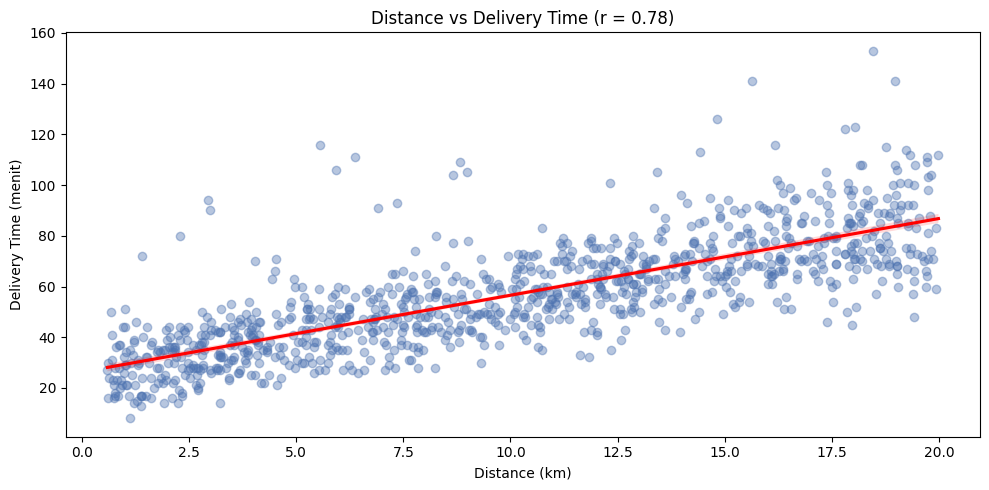

In [ ]:
#Scatter Plot Distance vs Delivery_Time

plt.figure(figsize=(10, 5))

sns.regplot(
    data=df_clean, x='Distance_km', y='Delivery_Time_min',
    scatter_kws={'alpha': 0.4, 'color': '#4C72B0'},
    line_kws={'color': 'red'}
)

r = df_clean['Distance_km'].corr(df_clean['Delivery_Time_min'])
plt.title(f'Distance vs Delivery Time (r = {r:.2f})')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (menit)')
plt.tight_layout()
plt.show()

####Scatter plot antara Distance_km dan Delivery_Time_min memperlihatkan hubungan linear positif yang kuat, sesuai dengan hasil correlation heatmap. Garis tren menunjukkan kecenderungan delivery time meningkat seiring bertambahnya jarak tempuh.

####Namun, sebaran data semakin lebar pada jarak yang lebih tinggi. Pada jarak sekitar 0–5 km, delivery time cenderung berada pada rentang yang lebih sempit, sedangkan pada jarak sekitar 15–20 km variasinya terlihat lebih besar. Hal ini menunjukkan bahwa meskipun jarak memiliki hubungan yang kuat dengan delivery time, terdapat faktor lain yang kemungkinan turut berhubungan dengan variasi waktu pengiriman.

##D.) Statistical Analysis & Business Insights

####Analisis boxplot per kategori telah menunjukkan adanya perbedaan visual dari masing-masing kategori (Weather, Traffic_Level, Vehicle_Type, Time_of_Day) dalam mempengaruhi delivery time. Namun, perbedaan yang tampak secara visual tersebut belum tentu mencerminkan pengaruh yang nyata. Bisa saja hal tersebut terjadi hanya karena kebetulan semata.

####Oleh karena itu, sebelum melakukan uji hipotesis terlebih dahulu dilakukan uji normalitas untuk menentukan metode uji yang tepat digunakan. Hasil uji tersebut kemudian menjadi dasar dalam memilih uji hipotesis yang sesuai, guna mengonfirmasi signifikansi perbedaan antar kategori sekaligus mengukur seberapa besar "kemampuan" masing-masing faktor dalam mempengaruhi delivery time secara kuantitatif melalui perhitungan effect size.

##D.1.) Uji Normalitas

####Sebelum menentukan uji hipotesis yang digunakan untuk membandingkan delivery time antar kategori, dilakukan pemeriksaan distribusi data sebagai salah satu pertimbangan dalam pemilihan metode statistik. Uji normalitas dilakukan menggunakan Shapiro-Wilk test, dengan hipotesis:

- H0 => data berdistribusi normal
- H1 => data tidak berdistribusi normal

####Hasil uji normalitas kemudian dipertimbangkan bersama karakteristik data dan tujuan analisis untuk menentukan metode pengujian yang sesuai.

In [ ]:
sample = df_clean['Delivery_Time_min'].sample(500, random_state=1)

stat, p_norm = stats.shapiro(sample)

print('W-statistic:', stat)
print(f'p-value: {p_norm:.7f}')

if p_norm < 0.05:
    print('Kesimpulan: p < 0.05 => tolak H0 => Terdapat bukti data tidak berdistribusi normal')
    print('=> Analisis dilanjutkan menggunakan uji non-parametrik Kruskal-Wallis')
else:
    print('Kesimpulan: p >= 0.05 => gagal tolak H0 => Tidak terdapat bukti yang cukup bahwa data tidak normal')
    print('=> Pemilihan uji parametrik/non-parametrik Tetap mempertimbangkan asumsi dan karakteristik data')

W-statistic: 0.9846962621953564
p-value: 0.0000409
Kesimpulan: p < 0.05 => tolak H0 => Terdapat bukti data tidak berdistribusi normal
=> Analisis dilanjutkan menggunakan uji non-parametrik Kruskal-Wallis


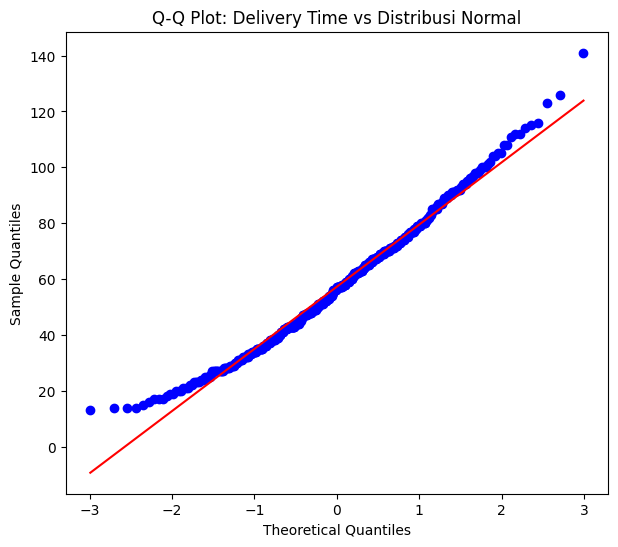

In [ ]:
sample = df_clean['Delivery_Time_min'].sample(500, random_state=1)

plt.figure(figsize=(7, 6))
stats.probplot(sample, dist="norm", plot=plt)
plt.title('Q-Q Plot: Delivery Time vs Distribusi Normal')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

####Hasil uji Shapiro-Wilk menunjukkan nilai W = 0,9847 dengan p-value = 0,0000409, yang berada di bawah ambang batas 0,05. Dengan demikian, H0 ditolak dan terdapat bukti bahwa data Delivery_Time_min tidak berdistribusi normal. Temuan ini juga konsisten dengan nilai skewness sebesar 0,507 yang menunjukkan distribusi condong ke kanan (C.2), serta histogram yang memperlihatkan adanya ekor distribusi pada delivery time yang tinggi.

####Karena karakteristik data menunjukkan penyimpangan dari normalitas, analisis perbedaan delivery time antar kelompok dilanjutkan menggunakan **Kruskal-Wallis H-test** sebagai metode non-parametrik.

##D.2.) Uji Hipotesis

####Pengujian hipotesis dilanjutkan menggunakan Kruskal-Wallis H-tes, uji non-parametrik yang dirancang untuk membandingkan tiga kelompok independen atau lebih tanpa mensyaratkan asumsi normalitas. Uji ini diterapkan pada seluruh variabel kategorikal untuk menentukan apakah masing-masing memiliki pengaruh yang signifikan terhadap delivery time, dengan hipotesis:

- H0: Tidak ada perbedaan delivery time antar kelompok (median/ranking sama)
- H1: Minimal ada satu kelompok dengan delivery time yang berbeda secara signifikan

In [ ]:
results = []
for col in ['Weather', 'Traffic_Level', 'Vehicle_Type', 'Time_of_Day']:
    groups = [g['Delivery_Time_min'].values for _, g in df_clean.groupby(col)]
    h, p = stats.kruskal(*groups)
    results.append({
        'Variabel': col,
        'H-statistic': round(h, 2),
        'p-value': p,
        'Kesimpulan': 'Signifikan' if p < 0.05 else 'Tidak signifikan'
    })

kw_results = pd.DataFrame(results)
kw_results

kw_results_display = kw_results.copy()
kw_results_display['p-value'] = kw_results_display['p-value'].apply(lambda x: f'{x:.9f}')
kw_results_display

,Variabel,H-statistic,p-value,Kesimpulan
0,Weather,37.05,0.000000176,Signifikan
1,Traffic_Level,37.07,0.000000009,Signifikan
2,Vehicle_Type,0.99,0.611028075,Tidak signifikan
3,Time_of_Day,0.94,0.816184941,Tidak signifikan


####Hasil pengujian Kruskal-Wallis menunjukkan adanya perbedaan delivery time yang signifikan pada variabel Weather (H = 37,05; p < 0,00001) dan Traffic_Level (H = 37,07; p < 0,00001). Karena p-value kedua variabel berada di bawah ambang batas 0,05, H0 ditolak. Dengan demikian, terdapat bukti statistik bahwa delivery time tidak memiliki distribusi yang sama pada seluruh kategori Weather maupun Traffic_Level.

####Sebaliknya, Vehicle_Type (H = 0,99; p = 0,611) dan Time_of_Day (H = 0,94; p = 0,816) memiliki p-value di atas 0,05. Oleh karena itu, H0 gagal ditolak dan tidak terdapat bukti statistik yang cukup untuk menyatakan adanya perbedaan delivery time antar kategori pada kedua variabel tersebut.

####Hasil Kruskal-Wallis hanya menunjukkan bahwa terdapat perbedaan pada setidaknya satu kelompok, sehingga belum dapat menunjukkan kategori mana yang berbeda secara spesifik.

###D.3.) Effect Size

####Hasil Kruskal-Wallis di tahap sebelumnya baru menjawab "ada/tidak ada pengaruh" secara statistik (lewat p-value), tapi belum menjawab "seberapa besar" pengaruh tersebut. Untuk itu, dihitung effect size menggunakan epsilon-squared (ε²), ukuran yang mencerminkan proporsi variasi delivery time yang dapat dijelaskan oleh masing-masing variabel kategorikal, dengan rumus:

####ε² = (H − k + 1) / (n − k)

####di mana H adalah H-statistic dari Kruskal-Wallis, k adalah jumlah kelompok, dan n adalah total observasi. Hasilnya diinterpretasikan menggunakan ambang batas umum: <0,01 (sangat kecil), 0,01–0,08 (kecil), 0,08–0,26 (sedang), dan >0,26 (besar).

In [ ]:
def interpret_eps2(eps2):
    if eps2 < 0.01:
        return 'Sangat kecil'
    elif eps2 < 0.08:
        return 'Kecil'
    elif eps2 < 0.26:
        return 'Sedang'
    else:
        return 'Besar'

n = len(df_clean)
effect_results = []

for col in ['Weather', 'Traffic_Level', 'Vehicle_Type', 'Time_of_Day']:
    k = df_clean[col].nunique()
    groups = [g['Delivery_Time_min'].values for _, g in df_clean.groupby(col)]
    h, p = stats.kruskal(*groups)
    eps2 = (h - k + 1) / (n - k)
    effect_results.append({
        'Variabel': col,
        'H-statistic': round(h, 2),
        'epsilon_squared': round(eps2, 4),
        '% variance explained': round(eps2 * 100, 1),
        'Interpretasi': interpret_eps2(eps2)
    })

effect_df = pd.DataFrame(effect_results)
effect_df

,Variabel,H-statistic,epsilon_squared,% variance explained,Interpretasi
0,Weather,37.05,0.0332,3.3,Kecil
1,Traffic_Level,37.07,0.0352,3.5,Kecil
2,Vehicle_Type,0.99,-0.0010,-0.1,Sangat kecil
3,Time_of_Day,0.94,-0.0021,-0.2,Sangat kecil


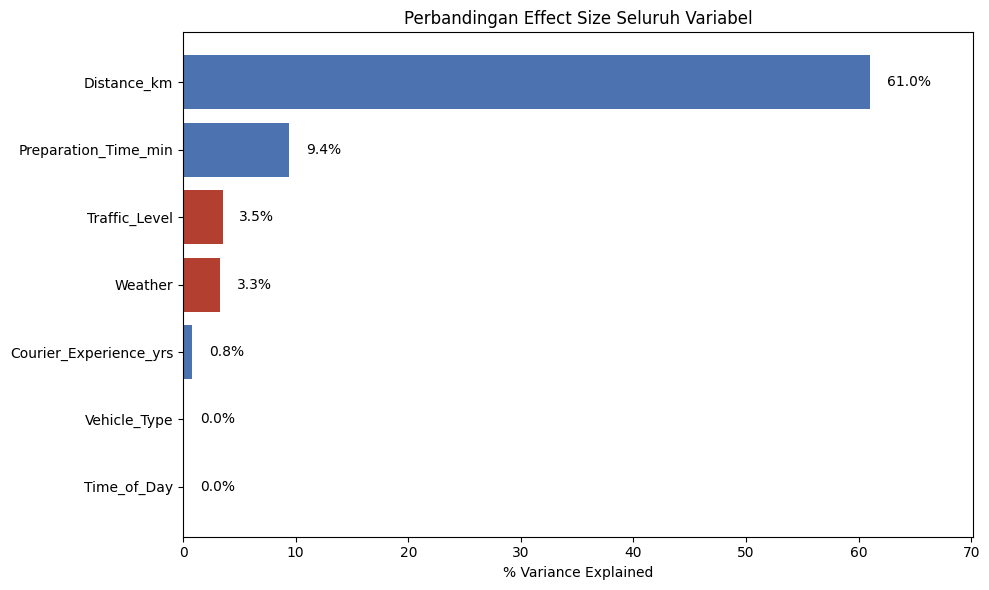

In [ ]:
combined = pd.DataFrame({
    'Variabel': ['Distance_km', 'Preparation_Time_min', 'Traffic_Level',
                 'Weather', 'Courier_Experience_yrs', 'Vehicle_Type', 'Time_of_Day'],
    'Effect_size_pct': [61.0, 9.4, 3.5, 3.3, 0.8, 0.0, 0.0],
    'Signifikan': ['-', '-', 'Ya', 'Ya', '-', 'Tidak', 'Tidak']
}).sort_values('Effect_size_pct', ascending=True)

colors = ['#B23F30' if s == 'Ya' else '#4C72B0' if s == '-' else '#B0B7C0'
          for s in combined['Signifikan']]

plt.figure(figsize=(10, 6))
plt.barh(combined['Variabel'], combined['Effect_size_pct'], color=colors)
for i, v in enumerate(combined['Effect_size_pct']):
    plt.text(v + 1.5, i, f'{v}%', va='center', fontsize=10)

plt.xlim(0, combined['Effect_size_pct'].max() * 1.15)
plt.xlabel('% Variance Explained')
plt.title('Perbandingan Effect Size Seluruh Variabel')
plt.tight_layout()
plt.show()

####Perhitungan epsilon-squared menunjukkan bahwa Weather (ε²=0,033; 3,3%) dan Traffic_Level (ε²=0,035; 3,5%). Meskipun keduanya signifikan secara statistik, mereka hanya menjelaskan porsi kecil dari total variasi delivery time menurut ambang interpretasi yang digunakan. Sementara itu, Vehicle_Type dan Time_of_Day memiliki epsilon-squared mendekati nol (bahkan negatif secara komputasi, yang secara praktis diinterpretasikan sebagai sangat kecil/negligible), konsisten dengan hasil p-value yang tidak signifikan pada tahap sebelumnya.

####Temuan ini melengkapi hasil korelasi yang telah dihitung sebelumnya, di mana Distance_km menjelaskan 61% variasi delivery time (r²=0,61), jauh melampaui gabungan Weather dan Traffic_Level (3,3% + 3,5% = 6,8%). Dengan demikian, dapat disimpulkan bahwa meskipun cuaca dan traffic terbukti berpengaruh secara statistik. Keduanya berperan sebagai faktor modifier terhadap estimasi dasar yang berbasis jarak, bukan sebagai driver utama delivery time.

####Effect size individual dari Weather (3,3%) dan Traffic_Level (3,5%) tergolong kecil bila dilihat terpisah. Namun, apakah efek keduanya bisa dijumlahkan/dikalikan begitu saja untuk memprediksi kombinasi? Untuk mengujinya, dilakukan simulasi sederhana: memprediksi delivery time tiap kombinasi Traffic × Weather menggunakan model multiplier naif (rata-rata keseluruhan dikalikan faktor pengali masing-masing kategori), lalu dibandingkan dengan nilai aktual dari data.

In [ ]:
overall_mean = df_clean['Delivery_Time_min'].mean()
traffic_mean = df_clean.groupby('Traffic_Level')['Delivery_Time_min'].mean()
weather_mean = df_clean.groupby('Weather')['Delivery_Time_min'].mean()
actual_pivot = df_clean.pivot_table(
    index='Traffic_Level', columns='Weather',
    values='Delivery_Time_min', aggfunc='mean'
)

rows = []
for t in ['Low', 'Medium', 'High']:
    for w in ['Clear', 'Windy', 'Foggy', 'Rainy', 'Snowy']:
        t_mult = traffic_mean[t] / overall_mean
        w_mult = weather_mean[w] / overall_mean
        predicted = overall_mean * t_mult * w_mult
        actual = actual_pivot.loc[t, w]
        rows.append((t, w, round(predicted, 1), round(actual, 1), round(actual - predicted, 1)))

simulasi_df = pd.DataFrame(rows, columns=['Traffic', 'Weather', 'Predicted (multiplier)', 'Actual', 'Selisih'])
print('MAE:', (simulasi_df['Actual'] - simulasi_df['Predicted (multiplier)']).abs().mean().round(2), 'menit')
simulasi_df

MAE: 2.59 menit


,Traffic,Weather,Predicted (multiplier),Actual,Selisih
0,Low,Clear,49.5,49.9,0.4
1,Low,Windy,51.7,51.4,-0.3
2,Low,Foggy,55.4,53.3,-2.1
3,Low,Rainy,55.7,55.0,-0.7
4,Low,Snowy,62.6,61.9,-0.6
5,Medium,Clear,52.9,54.2,1.4
6,Medium,Windy,55.2,53.8,-1.4
7,Medium,Foggy,59.2,63.0,3.9
8,Medium,Rainy,59.5,55.1,-4.4
9,Medium,Snowy,66.8,71.7,4.9


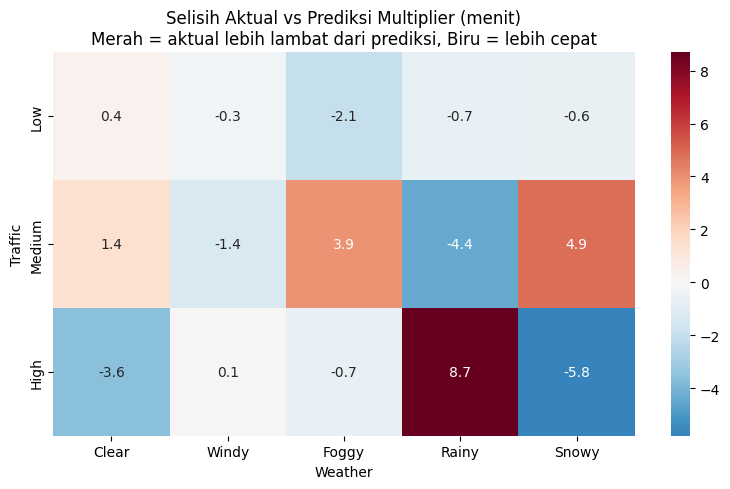

In [ ]:
diff_pivot = simulasi_df.pivot(index='Traffic', columns='Weather', values='Selisih')
order_t = ['Low', 'Medium', 'High']
order_w = ['Clear', 'Windy', 'Foggy', 'Rainy', 'Snowy']
diff_pivot = diff_pivot.reindex(index=order_t, columns=order_w)

plt.figure(figsize=(8, 5))
sns.heatmap(diff_pivot, annot=True, fmt='.1f', cmap='RdBu_r', center=0)
plt.title('Selisih Aktual vs Prediksi Multiplier (menit)\nMerah = aktual lebih lambat dari prediksi, Biru = lebih cepat')
plt.tight_layout()
plt.show()

####Simulasi ini membuktikan bahwa efek Weather dan Traffic_Level tidak bersifat independen. Rata-rata selisih prediksi vs aktual (MAE) mencapai 2,59 menit, dengan penyimpangan terbesar pada kombinasi High + Rainy (meleset +8,7 menit) dan High + Snowy (meleset −5,8 menit). Artinya, dampak gabungan traffic tinggi dan hujan saling memperkuat melebihi perkiraan sederhana, sementara kombinasi traffic tinggi dan salju justru saling menutupi (lebih ringan dari perkiraan).

####Fenomena ini disebut efek interaksi, dan menjadi alasan kuantitatif mengapa effect size individual yang kecil (3,3% dan 3,5%) tidak boleh dijumlahkan secara naif untuk memahami dampak kombinasi kondisi ekstrem. Kombinasi kondisi perlu dianalisis dan ditangani sebagai pola tersendiri, bukan sekadar penjumlahan dua faktor terpisah.

##E.) Actionable Business Insights

1. Estimasi waktu pengiriman belum adaptif terhadap kondisi lapangan
Analisis membuktikan gap yang nyata: delivery time pada kombinasi traffic High + cuaca Rainy mencapai 77 menit, dibanding 49,9 menit pada kondisi terbaik (Low + Clear), selisih 54% lebih lambat. Ini mengonfirmasi bahwa estimasi waktu yang seragam untuk semua kondisi berisiko jauh meleset dari realita di kondisi ekstrem. **Rekomendasi: terapkan estimasi berbasis lookup table dari data historis per kombinasi Traffic × Weather (bukan angka tunggal untuk semua kondisi), sebagai penyesuaian cepat tanpa perlu membangun model prediktif.**

2. Faktor operasional yang benar-benar berpengaruh signifikan
Uji Kruskal-Wallis mengonfirmasi hanya Weather dan Traffic_Level yang berpengaruh signifikan terhadap delivery time (p < 0,00001), sementara Vehicle_Type dan Time_of_Day terbukti tidak signifikan (p > 0,05). Di sisi lain, Distance_km adalah driver dominan, menjelaskan 61% variasi delivery time. Jauh melampaui gabungan Weather dan Traffic_Level (6,8%). **Rekomendasi: prioritaskan distance sebagai basis utama estimasi waktu, dengan cuaca dan traffic sebagai faktor penyesuaian; hentikan alokasi effort untuk mengoptimalkan berdasarkan jenis kendaraan atau waktu pemesanan, karena keduanya tidak terbukti berdampak.**

3. Kuantifikasi dampak kombinasi kondisi buruk
Secara individual, pengaruh Weather (ε² = 3,3%) dan Traffic_Level (ε² = 3,5%) tergolong kecil. Namun, kombinasi keduanya menunjukkan efek interaksi yang nyata: kondisi Snowy secara konsisten berat di semua level traffic (rata-rata 68,2 menit), sedangkan Rainy justru melonjak drastis saat bertemu traffic High (55 → 77 menit). Menandakan dampaknya saling memperkuat, bukan sekadar dijumlahkan. **Rekomendasi: kebijakan buffer waktu perlu dibedakan polanya, buffer konsisten untuk cuaca Snowy apapun kondisi traffic-nya, dan buffer khusus untuk Rainy saat traffic terpantau tinggi.**
**bold text**
4. Risiko komplain akibat gap ekspektasi
Dataset ini tidak memiliki data ETA historis, sehingga gap ekspektasi vs realita belum dapat diukur langsung. Namun, dengan bukti bahwa delivery time bisa bervariasi hingga 54% antar kondisi, risiko gap tersebut sangat mungkin terjadi jika estimasi masih statis. **Rekomendasi: mulai mencatat ETA yang ditampilkan ke pelanggan vs delivery time aktual, sebagai data lanjutan untuk mengukur efektivitas penyesuaian estimasi yang direkomendasikan pada poin 1 dan 3.**

In [ ]:
df_clean.to_csv('Ubers.csv', index=False)
effect_df.to_csv('effect_size.csv', index=False)